# 🐦‍🔥 ¡Clasifícalos Ya! 🪼

## 🎯 ¿Qué se busca hacer?
El objetivo de este proyecto es crear un modelo de clasificación multietiqueta para la predicción de los tipos de un Pokémon.

El modelo se basará únicamente en las características fisiológicas (la apariencia visual) de cada Pokémon. Deberá aprender a identificar patrones en las imágenes que se correlacionen con un tipo elemental, como "Fuego" 🔥, "Agua" 💧 o "Planta" 🌿.

Se utiliza un enfoque de clasificación multietiqueta porque, como sabemos, muchos Pokémon poseen dos tipos simultáneamente (por ejemplo, Bulbasaur es "Planta" y "Veneno").

![Imagen de Bulbasaur](https://assets.pokemon.com/assets/cms2/img/pokedex/full/001.png)

## 🏷️ Tipos (Etiquetas) del Proyecto
La lista completa de tipos que el modelo aprenderá a identificar es:

- Normal

- Fuego 🔥

- Agua 💧

- Eléctrico ⚡

- Planta 🌿

- Hielo ❄️

- Lucha 🥊

- Veneno ☠️

- Tierra ⛰️

- Volador 🐦

- Bicho 🐛

- Psíquico 🌀

- Hada ✨

- Roca 🗿

- Fantasma 👻

- Dragón 🐲

- Siniestro 🌙

- Acero ⚙️

## 💾 El Conjunto de Datos (Dataset)
---
### Origen de los datos

El dataset se obtuvo directamente de Kaggle:

* [Complete Pokémon Library (32k Images and CSV)](https://www.kaggle.com/datasets/divyanshusingh369/complete-pokemon-library-32k-images-and-csv)
* [Pokemon Image Dataset](https://www.kaggle.com/datasets/vishalsubbiah/pokemon-images-and-types?select=images)

Este conjunto de datos es una recopilación exhaustiva que incluye a todos los Pokémon hasta la novena generación.

---

### Composición del Dataset
El dataset se divide en dos componentes principales: las imágenes y los archivos de metadatos.

1. Las Imágenes (Más de 32,000 archivos)

* La colección de imágenes es muy rica y proporciona múltiples vistas de cada Pokémon, lo cual es fundamental para el entrenamiento del modelo:

    * Imágenes frontales (vista de frente).

    * Imágenes traseras (vista de espalda).

    * Versión Normal: La paleta de colores estándar.

    * Versión Variocolor (Shiny): La versión con colores alternativos, una variante visual especial de cada Pokémon.

2. Los Metadatos (Archivos CSV y JSON)
* Para etiquetar las imágenes, el dataset incluye archivos que describen a cada Pokémon:

    * Archivo pokemon.csv: Contiene la información básica y esencial, incluyendo:

    * Nombre

    * Tipo 1 y Tipo 2 (nuestras etiquetas objetivo)

    * Especie

    * Altura

    * Peso

    * Y más...

* Archivo JSON: Ofrece atributos de juego mucho más detallados y completos. (Aunque no usaremos todos para este proyecto, es bueno saber que existen):

    * Atributos (Tipo, Especie, Habilidades, etc.)
    
    * Valores de Esfuerzo (EV yield)
    
    * Ratio de Captura, Amistad Base, Experiencia Base
    
    * Grupos Huevo, Género y Ciclos de Huevo
    
    * Estadísticas Base: HP, Ataque, Defensa, Ataque Especial, Defensa Especial y Velocidad.

---

## 🔬 Desafíos Técnicos del Proyecto
Además de la naturaleza multietiqueta, el proyecto presenta varias complicaciones significativas que deben abordarse para que el modelo sea preciso:

* Desbalance de Clases (imbalance): Existe una gran disparidad en la cantidad de Pokémon por tipo. Por ejemplo, el dataset contiene 176 Pokémon de tipo Agua 💧, pero solo 65 de tipo Hielo ❄️. Este desbalance puede hacer que el modelo se "sobreajuste" a los tipos más comunes e ignore los menos frecuentes, requiriendo técnicas especiales de manejo de datos o ponderación de pérdidas.

* Similitud Interclase (Inter-class Similarity): Algunos Pokémon de tipos distintos tienen apariencias muy similares. Un claro ejemplo son Zubat (Veneno/Volador) y Woobat (Psíquico/Volador). El modelo debe aprender a diferenciar patrones visuales muy sutiles para no confundirlos.

![Imagen Zubat](https://assets.pokemon.com/assets/cms2/img/pokedex/full/041.png)        ![Imagen Woobat](https://assets.pokemon.com/assets/cms2/img/pokedex/full/527.png)


* Variabilidad Intraclase (Intra-class Variability): Este es el problema opuesto, no todos los Pokémon del mismo tipo se parecen entre sí. Por ejemplo, tanto Charmander como Magcargo son de tipo "Fuego" 🔥, pero visualmente son completamente diferentes (un lagarto bípedo y un caracol de lava). El modelo debe encontrar una característica visual subyacente que los conecte, más allá de la simple forma o color.

![Imagen Charmander](https://assets.pokemon.com/assets/cms2/img/pokedex/full/004.png)        ![Imagen Magcargo](https://assets.pokemon.com/assets/cms2/img/pokedex/full/219.png)

## Librerias

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import os
import re
import cv2
import pickle
import random
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization, Activation, Add, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D, Flatten, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall
from collections import Counter

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
gpus_disponibles = tf.config.list_physical_devices('GPU')

if len(gpus_disponibles) > 0:
    print(f"✅ ¡GPU de Colab detectada exitosamente!")
    for gpu in gpus_disponibles:
        print(f"  -> {gpu}")
else:
    print("❌ ERROR: No se detectó ninguna GPU.")

✅ ¡GPU de Colab detectada exitosamente!
  -> PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## Revision Del CSV

In [7]:
# Ruta
path_pokemon = '/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/pokemonDB_dataset.csv'

In [8]:
# Carga de datos
df = pd.read_csv(path_pokemon)

# Inspección de datos
print("--- 1. Vista Previa del Dataset (Primeras 5 Filas) ---")
print(df.head())
print("="*60 + "\n")

--- 1. Vista Previa del Dataset (Primeras 5 Filas) ---
          Pokemon        Type             Species         Height  \
0       Abomasnow  Grass, Ice  Frost Tree Pokémon  2.2 m (7′03″)   
1  Mega Abomasnow  Grass, Ice  Frost Tree Pokémon  2.7 m (8′10″)   
2            Abra     Psychic         Psi Pokémon  0.9 m (2′11″)   
3           Absol        Dark    Disaster Pokémon  1.2 m (3′11″)   
4      Mega Absol        Dark    Disaster Pokémon  1.2 m (3′11″)   

                 Weight                                          Abilities  \
0  135.5 kg (298.7 lbs)       1. Snow Warning, Soundproof (hidden ability)   
1  185.0 kg (407.9 lbs)                                    1. Snow Warning   
2    19.5 kg (43.0 lbs)  1. Synchronize, 2. Inner Focus, Magic Guard (h...   
3   47.0 kg (103.6 lbs)  1. Pressure, 2. Super Luck, Justified (hidden ...   
4   49.0 kg (108.0 lbs)                                    1. Magic Bounce   

              EV Yield                          Catch Rate  \
0  1 

In [9]:
df = pd.read_csv(path_pokemon)
columna_nombres = 'Pokemon'
# --- Imprimir todos los valores de esa columna ---
print(f"--- Mostrando todos los {len(df)} nombres de la columna '{columna_nombres}' ---")

if columna_nombres in df.columns:
    print(df[columna_nombres].to_string())
else:
    print(f"Error: La columna '{columna_nombres}' no existe en el CSV.")

--- Mostrando todos los 1215 nombres de la columna 'Pokemon' ---
0                               Abomasnow
1                          Mega Abomasnow
2                                    Abra
3                                   Absol
4                              Mega Absol
5                                Accelgor
6                  Aegislash Shield Forme
7                   Aegislash Blade Forme
8                              Aerodactyl
9                         Mega Aerodactyl
10                                 Aggron
11                            Mega Aggron
12                                  Aipom
13                               Alakazam
14                          Mega Alakazam
15                               Alcremie
16                              Alomomola
17                                Altaria
18                           Mega Altaria
19                                 Amaura
20                                Ambipom
21                              Amoonguss
22         

In [10]:
print("--- 2. Información del DataFrame (Columnas, Tipos, Nulos) ---")
df.info()

--- 2. Información del DataFrame (Columnas, Tipos, Nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Pokemon               1215 non-null   object
 1   Type                  1215 non-null   object
 2   Species               1215 non-null   object
 3   Height                1215 non-null   object
 4   Weight                1215 non-null   object
 5   Abilities             1215 non-null   object
 6   EV Yield              1215 non-null   object
 7   Catch Rate            1215 non-null   object
 8   Base Friendship       1215 non-null   object
 9   Base Exp              1215 non-null   object
 10  Growth Rate           1215 non-null   object
 11  Egg Groups            1215 non-null   object
 12  Gender                1215 non-null   object
 13  Egg Cycles            1215 non-null   object
 14  HP Base               1215

In [11]:
print("Solo los tipos de los primeros 10 pokemones:")
print(df['Type'].head(10))

Solo los tipos de los primeros 10 pokemones:
0      Grass, Ice
1      Grass, Ice
2         Psychic
3            Dark
4            Dark
5             Bug
6    Steel, Ghost
7    Steel, Ghost
8    Rock, Flying
9    Rock, Flying
Name: Type, dtype: object


In [12]:
# Dividir los tipos múltiples en listas
listas_de_tipos = df['Type'].str.split(',')

conteo_tipos = Counter()

for lista in listas_de_tipos:
        # Creamos una lista limpia para cada Pokémon
        tipos_limpios = []
        for tipo in lista:
            # .strip() elimina espacios en blanco al inicio o final
            # ej. " Ice" -> "Ice"
            tipos_limpios.append(tipo.strip())

        # Actualizamos el conteo con los tipos limpios
        conteo_tipos.update(tipos_limpios)

In [13]:
print("--- Conteo Total de Pokémon por Tipo ---")
print("(Basado en la columna 'Type' dividida)\n")

# .most_common() ya nos da la lista ordenada de mayor a menor
for tipo, conteo in conteo_tipos.most_common():
    print(f"{tipo}: {conteo}")

print("\n-------------------------------------")
print(f"Total de tipos únicos encontrados: {len(conteo_tipos)}")

--- Conteo Total de Pokémon por Tipo ---
(Basado en la columna 'Type' dividida)

Water: 176
Normal: 153
Grass: 146
Psychic: 134
Flying: 132
Bug: 100
Fire: 97
Poison: 96
Dragon: 93
Fighting: 92
Ground: 90
Dark: 89
Rock: 88
Ghost: 87
Electric: 87
Steel: 85
Fairy: 74
Ice: 65

-------------------------------------
Total de tipos únicos encontrados: 18


## Seleccion de imagenes

In [14]:
def normalize_name(name):
    """
    Limpia un nombre de Pokémon para que coincida
    entre el CSV y los nombres de las carpetas.
    """
    if not isinstance(name, str):
        name = str(name)


    # 2. Quitar paréntesis y espacios
    #    (Hacemos esto primero para limpiar formatos)
    name = name.replace("(", "").replace(")", "")

    # 3. Reemplazar caracteres especiales
    name = name.replace('♀', '-f')       # Nidoran♀ -> nidoran-f
    name = name.replace('♂', '-m')       # Nidoran♂ -> nidoran-m
    name = name.replace("'", "")       # Farfetch'd -> farfetchd
    name = name.replace(".", "")       # Mime Jr. -> mimejr
    name = name.replace("_", "-")      # Farfetch_d -> farfetch-d

    return name

### ♂ Nidoran ♀: Un Caso Especial en el Preprocesamiento
Los Pokémon Nidoran♀ y Nidoran♂ representan un desafío particular en la fase de limpieza y procesamiento de datos. A pesar de ser evoluciones del mismo Pokémon base y compartir muchas características, son entradas distintas con géneros específicos, lo que se denota con los símbolos ♀ (femenino) y ♂ (masculino) en sus nombres oficiales.

Esto genera dos puntos clave que requieren un tratamiento especial:

Entradas Distintas: Aunque comparten el mismo origen, el dataset los trata como entidades separadas con sus propios identificadores, lo cual es correcto desde una perspectiva de juego, pero exige una normalización cuidadosa para asegurar la correspondencia con las imágenes y evitar duplicidades semánticas si nuestro objetivo fuera agruparlos por su "línea evolutiva" base (aunque para este proyecto los trataremos como entidades separadas y sus símbolos ♀/♂ se convertirán a -f/-m para la normalización).

![Hembra](https://assets.pokemon.com/assets/cms2/img/pokedex/full/029.png)  ![Macho](https://assets.pokemon.com/assets/cms2/img/pokedex/full/032.png)

In [15]:
print("Creando mapa de etiquetas normalizado...")

label_map = {}

for index, row in df.iterrows():

    # Obtener el nombre "sucio" del CSV
    nombre_pokemon_csv = row['Pokemon']

    # Manejar los casos especiales de Nidoran

    if "Nidoran♀ (female)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♀"
    elif "Nidoran♂ (male)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♂"
    else:
        # Si no es un caso especial, usar el nombre tal cual
        nombre_a_normalizar = nombre_pokemon_csv

    # 1. Normalizar el nombre (ya sea el original o el pre-limpiado)
    nombre_normalizado = normalize_name(nombre_a_normalizar)

    # 2. Obtener los tipos
    tipos_str = row['Type']
    lista_de_tipos = [tipo.strip() for tipo in tipos_str.split(',')]

    # 3. Guardar en el mapa con la clave normalizada
    if nombre_normalizado not in label_map:
        label_map[nombre_normalizado] = lista_de_tipos
    else:
        pass

print(f"--- Mapa de Etiquetas Creado. {len(label_map)} entradas únicas. ---")

# (Opcional) Verifica que los nombres clave se normalizaron bien
print("\nEjemplo del mapa (normalizado):")
print(f"'nidoran-f': {label_map.get('nidoran-f')}")
print(f"'nidoran-m': {label_map.get('nidoran-m')}")
print(f"'aegislashbladeforme': {label_map.get('aegislashbladeforme')}")
print(f"'farfetchd': {label_map.get('farfetchd')}")
print(f"'mimejr': {label_map.get('mimejr')}")

Creando mapa de etiquetas normalizado...
--- Mapa de Etiquetas Creado. 1215 entradas únicas. ---

Ejemplo del mapa (normalizado):
'nidoran-f': None
'nidoran-m': None
'aegislashbladeforme': None
'farfetchd': None
'mimejr': None


In [16]:
if not os.path.exists("/content/pokemon1"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Images DB.zip" "/content/pokemon1.zip"
  print("¡Copia finalizada!")
  # --- PASO 2: Descomprimir el ZIP en el disco local ---
  # Esto es súper rápido.
  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon1.zip -d /content/pokemon1
  print("¡Dataset listo en /content/pokemon1!")
else:
  print("El dataset ya está en /content/pokemon1")

Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon1!


In [17]:
if not os.path.exists("/content/pokemon2"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Dataset.zip" "/content/pokemon2.zip"
  print("¡Copia finalizada!")

  # --- PASO 2: Descomprimir el ZIP en el disco local ---
  # Esto es súper rápido.
  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon2.zip -d /content/pokemon2
  print("¡Dataset listo en /content/pokemon2!")
else:
  print("El dataset ya está en /content/pokemon2")

Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon2!


In [18]:
if not os.path.exists("/content/pokemon3"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Fotos Pokemon1.zip" "/content/pokemon3.zip"
  print("¡Copia finalizada!")

  # --- PASO 2: Descomprimir el ZIP en el disco local ---
  # Esto es súper rápido.
  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon3.zip -d /content/pokemon3
  print("¡Dataset listo en /content/pokemon3!")
else:
  print("El dataset ya está en /content/pokemon3")

Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon3!


In [19]:
carpeta_raiz = '/content/pokemon1'
X_rutas_imagenes = []
y_etiquetas = []

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")

# Busqueda de imagenes en otra ruta
# --- Celda 2b: Explorar y AÑADIR desde la segunda carpeta ---

carpeta_raiz_nueva = r'/content/pokemon2'

print(f"\nIniciando exploración de la segunda fuente de datos: {carpeta_raiz_nueva}...")
imagenes_encontradas_antes = len(X_rutas_imagenes)

# Usamos os.walk para explorar la nueva ruta
for root, dirs, files in os.walk(carpeta_raiz_nueva):

    # 2. Filtrar: Buscamos carpetas que sean 'normal' y no 'shiny'
    #    Usamos .lower() para encontrar 'normal' o 'Normal'
    if os.path.sep + 'normal' in root.lower() and 'shiny' not in root.lower():

        # 3. Extraer el nombre del Pokémon
        try:
            partes_ruta = root.split(os.path.sep)

            # La carpeta 'normal' es la de [version]
            # La ruta es: ...\[nombrepokemon]\[generacion]\[juego]\[version]
            # Por lo tanto, el nombre está 3 niveles "arriba" de 'normal'

            # Encontramos el índice de la carpeta 'normal' (o 'Normal')
            idx_normal = -1
            for i, parte in enumerate(partes_ruta):
                if parte.lower() == 'normal':
                    idx_normal = i
                    break

            if idx_normal != -1 and idx_normal >= 3:
                # Extraemos el nombre: [idx_normal - 3]
                nombre_pokemon_folder = partes_ruta[idx_normal - 3]

                # 4. Normalizar el nombre (¡usando la misma función!)
                nombre_normalizado = normalize_name(nombre_pokemon_folder)

                # 5. Buscar en el mapa y añadir
                if nombre_normalizado in label_map:
                    for file_name in files:
                        # Nos aseguramos de tomar solo PNGs/JPGs (NO GIFs)
                        if file_name.endswith(('.png', '.jpg', '.jpeg')):
                            ruta_completa = os.path.join(root, file_name)
                            X_rutas_imagenes.append(ruta_completa)
                            y_etiquetas.append(label_map[nombre_normalizado])
                else:
                    # (Nos avisará si este nombre de carpeta no está en el CSV)
                    print(f"Advertencia (Fuente 2): Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada.")

        except Exception as e:
            print(f"Error procesando ruta {root}: {e}")

print("\n" + "-"*60)
print("Exploración de la segunda fuente de datos completada.")

carpeta_raiz = '/content/pokemon3'

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")


Iniciando exploración.
Advertencia: Carpeta 'Pokemon Images DB' (normalizado a 'Pokemon Images DB') no encontrada en el CSV.
Advertencia: Carpeta 'Kyurem (White Kyurem)' (normalizado a 'Kyurem White Kyurem') no encontrada en el CSV.
Advertencia: Carpeta 'Greninja (Ash-Greninja)' (normalizado a 'Greninja Ash-Greninja') no encontrada en el CSV.
Advertencia: Carpeta 'Rotom (Wash Rotom)' (normalizado a 'Rotom Wash Rotom') no encontrada en el CSV.
Advertencia: Carpeta 'Necrozma (Dusk Mane Necrozma)' (normalizado a 'Necrozma Dusk Mane Necrozma') no encontrada en el CSV.
Advertencia: Carpeta 'Hoopa (Hoopa Unbound)' (normalizado a 'Hoopa Hoopa Unbound') no encontrada en el CSV.
Advertencia: Carpeta 'Necrozma (Ultra Necrozma)' (normalizado a 'Necrozma Ultra Necrozma') no encontrada en el CSV.
Advertencia: Carpeta 'Hoopa (Hoopa Confined)' (normalizado a 'Hoopa Hoopa Confined') no encontrada en el CSV.
Advertencia: Carpeta 'Galarian Farfetch_d' (normalizado a 'Galarian Farfetch-d') no encontrada

## Modelo

## ¿Qué es la Binarización Multietiqueta?
Tu intuición es correcta: es un proceso muy similar al **One-Hot Encoding (OHE)**, pero adaptado para problemas donde una sola muestra puede tener múltiples etiquetas o categorías al mismo tiempo.

**One-Hot Encoding (OHE)**

Se utiliza cuando cada muestra solo puede pertenecer a una clase. El vector resultante siempre tiene un solo 1 y el resto son 0.

| Pokemon | Fuego 🔥 | Agua 💦 | Electrico ⚡ |
| ------------- |:-------------:| :-------------:| :-------------:|
| Charmander     | 1 | 0 | 0 |
| Squirtle      | 0 | 1 | 0 |
| Pikachu     | 0 | 0 | 1 |

**Multi-Label Binarizer (MLB)**

Se usa cuando cada muestra puede pertenecer a una o más clases. El vector resultante puede tener múltiples 1.

| Pokemon | Fuego 🔥 | Agua 💧 | Planta 🌿 | Veneno ☠️ |
| ------------- |:-------------:| :-------------:| :-------------:|  :-------------:|
| Charmander     | 1 | 0 | 0 | 0 |
| Squirtle      | 0 | 1 | 0 | 0 |
| Bulbasaur     | 0 | 0 | 1 | 1 |

**Conclusión**

Se estan convirtiendo los tipos de texto en un vector binario, justo como el **OHE**. Pero como un Pokémon puede tener dos tipos, usamos la versión "multietiqueta" **(MLB)** para permitir que más de un "1" esté "caliente" **(hot)** al mismo tiempo.

In [20]:
print("Iniciando binarización de las 15,032 etiquetas...")

mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y_etiquetas)

classes = mlb.classes_
num_classes = len(classes)

print("\n--- Binarizador de Etiquetas Creado ---")
print(f"Número total de clases (tipos) únicas: {num_classes}")
print(f"Clases encontradas: {classes}")

Iniciando binarización de las 15,032 etiquetas...

--- Binarizador de Etiquetas Creado ---
Número total de clases (tipos) únicas: 18
Clases encontradas: ['Bug' 'Dark' 'Dragon' 'Electric' 'Fairy' 'Fighting' 'Fire' 'Flying'
 'Ghost' 'Grass' 'Ground' 'Ice' 'Normal' 'Poison' 'Psychic' 'Rock' 'Steel'
 'Water']


In [21]:
with open('mlb_binarizer.pkl', 'wb') as f:
    pickle.dump(mlb, f)
print("\nBinarizador guardado como 'mlb_binarizer.pkl'")

print("\nDividiendo los 15,032 items en Train/Validation...")

X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_rutas_imagenes,
    y_binarized,
    test_size=0.2,
    random_state=42
)

print("\n--- Datos Divididos (Nuevos Totales) ---")
print(f"Imágenes de Entrenamiento (X_train_paths): {len(X_train_paths)}")
print(f"Etiquetas de Entrenamiento (y_train):     {len(y_train)}")
print(f"Imágenes de Validación (X_val_paths):   {len(X_val_paths)}")
print(f"Etiquetas de Validación (y_val):       {len(y_val)}")


Binarizador guardado como 'mlb_binarizer.pkl'

Dividiendo los 15,032 items en Train/Validation...

--- Datos Divididos (Nuevos Totales) ---
Imágenes de Entrenamiento (X_train_paths): 12025
Etiquetas de Entrenamiento (y_train):     12025
Imágenes de Validación (X_val_paths):   3007
Etiquetas de Validación (y_val):       3007


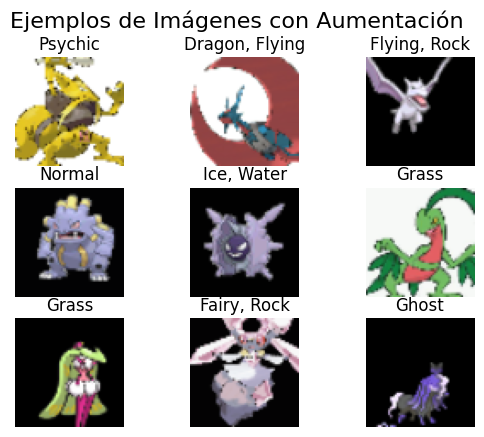

In [22]:
IMG_SIZE = 64
NUM_CLASSES = 18
BATCH_SIZE = 16

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label, augment=False):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    if augment:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
        h, w, _ = image.shape
        crop_h = tf.cast(tf.cast(h, tf.float32) * 0.85, tf.int32)
        crop_w = tf.cast(tf.cast(w, tf.float32) * 0.85, tf.int32)
        image = tf.image.random_crop(image, size=[crop_h, crop_w, 3])
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Normalizar
    image = image / 255.0

    return image, label

    plt.figure(figsize=(12, 12))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img_path = X_train_paths[i]
    label = y_train[i]

    image, _ = load_and_preprocess(img_path, label, augment=True)
    plt.imshow(image.numpy())

    tipos_pokemon = [classes[idx] for idx, val in enumerate(label) if val == 1]
    plt.title(", ".join(tipos_pokemon))
    plt.axis("off")
plt.suptitle("Ejemplos de Imágenes con Aumentación", fontsize=16)
plt.show()

In [23]:
# --- Pipeline de Entrenamiento ---
train_ds = tf.data.Dataset.from_tensor_slices((X_train_paths, y_train))
train_ds = train_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=True),
    num_parallel_calls=AUTOTUNE
)
train_ds = train_ds.shuffle(buffer_size=len(X_train_paths))
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# --- Pipeline de Validación ---
val_ds = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val))
val_ds = val_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=False),
    num_parallel_calls=AUTOTUNE
)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Pipelines de Entrenamiento (train_ds) y Validación (val_ds) creados.")
print(f"   -> train_ds: {train_ds}")
print(f"   -> val_ds:   {val_ds}")

✅ Pipelines de Entrenamiento (train_ds) y Validación (val_ds) creados.
   -> train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.int64, name=None))>
   -> val_ds:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.int64, name=None))>


In [24]:
def identity_block(X, f, filters, stage, block):
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base   = 'bn'  + str(stage) + block + '_branch'
    F1, F2, F3 = filters
    X_shortcut = X

    X = Conv2D(filters=F1, kernel_size=(1, 1), strides=(1, 1), padding='valid', name=conv_name_base + '2a', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F2, kernel_size=(f, f), strides=(1, 1), padding='same', name=conv_name_base + '2b', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F3, kernel_size=(1, 1), strides=(1, 1), padding='valid', name=conv_name_base + '2c', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2c')(X)

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    return X

def convolutional_block(X, f, filters, stage, block, s=2):
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base   = 'bn'  + str(stage) + block + '_branch'
    F1, F2, F3 = filters
    X_shortcut = X

    # MAIN PATH
    X = Conv2D(filters=F1, kernel_size=(1, 1), strides=(s, s), padding='valid', name=conv_name_base + '2a', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F2, kernel_size=(f, f), strides=(1, 1), padding='same', name=conv_name_base + '2b', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F3, kernel_size=(1, 1), strides=(1, 1), padding='valid', name=conv_name_base + '2c', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2c')(X)

    # SHORTCUT PATH
    X_shortcut = Conv2D(filters=F3, kernel_size=(1, 1), strides=(s, s), padding='valid', name=conv_name_base + '1', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X_shortcut)
    X_shortcut = BatchNormalization(axis=3, name=bn_name_base + '1')(X_shortcut)

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    return X

def ResNet50_Adaptada(input_shape, classes):
    X_input = Input(input_shape)
    X = ZeroPadding2D((3, 3))(X_input)

    # Stage 1
    X = Conv2D(64, (7, 7), strides=(2, 2), name='conv1', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name='bn_conv1')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f=3, filters=[64, 64, 256], stage=2, block='a', s=1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='b')
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='c')

    # Stage 3
    X = convolutional_block(X, f=3, filters=[128, 128, 512], stage=3, block='a', s=2)
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='b')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='c')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='d')

    # Stage 4
    X = convolutional_block(X, f=3, filters=[256, 256, 1024], stage=4, block='a', s=2)
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='b')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='c')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='d')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='e')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='f')

    # Stage 5
    X = convolutional_block(X, f=3, filters=[512, 512, 2048], stage=5, block='a', s=2)
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='b')
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='c')

    # HEAD
    X = GlobalAveragePooling2D(name='avg_pool')(X)

    X = Dense(classes, activation='sigmoid', name='fc' + str(classes), kernel_initializer=GlorotUniform(seed=0))(X)

    model = Model(inputs=X_input, outputs=X, name='ResNet50_Adaptada')
    return model

print("✅ Funciones de ResNet identity_block, convolutional_block, ResNet50_Adaptada.")

✅ Funciones de ResNet identity_block, convolutional_block, ResNet50_Adaptada.


In [25]:
model = ResNet50_Adaptada(input_shape=IMG_SHAPE, classes=NUM_CLASSES)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=[
                  BinaryAccuracy(name='accuracy'),
                  Precision(name='precition'),
                  Recall(name='recall')
              ])

print("✅ Modelo ResNet-50 creado y compilado exitosamente para Multi-Etiqueta.")
model.summary()

✅ Modelo ResNet-50 creado y compilado exitosamente para Multi-Etiqueta.


Model: "ResNet50_Adaptada"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 32,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 32, 32,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 15, 15,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2a      │ (None, 15, 15,    │      4,096 │ max_pooling2d[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2a       │ (None, 15, 15,    │        256 │ res2a_branch2a[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 15, 15,    │          0 │ bn2a_branch2a[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2b      │ (None, 15, 15,    │     36,864 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2b       │ (None, 15, 15,    │        256 │ res2a_branch2b[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 15, 15,    │          0 │ bn2a_branch2b[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2c      │ (None, 15, 15,    │     16,384 │ activation_2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch1       │ (None, 15, 15,    │     16,384 │ max_pooling2d[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2c       │ (None, 15, 15,    │      1,024 │ res2a_branch2c[0… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch1        │ (None, 15, 15,    │      1,024 │ res2a_branch1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 15,    │          0 │ bn2a_branch2c[0]

 Total params: 23,598,034 (90.02 MB)

 Trainable params: 23,544,914 (89.82 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [26]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,                 # Épocas a esperar sin mejora antes de parar
    mode='min',
    verbose=1,
    restore_best_weights=True    # Restaura los pesos del mejor modelo al final
)

callbacks_list = [early_stopping]

EPOCHS = 9

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_list
)

print("🚀 ¡Entrenamiento completado!")

Epoch 1/9
752/752 ━━━━━━━━━━━━━━━━━━━━ 121s 81ms/step - accuracy: 0.9083 - loss: 0.3684 - precition: 0.1308 - recall: 0.0183 - val_accuracy: 0.9170 - val_loss: 0.4162 - val_precition: 0.4854 - val_recall: 0.0111
Epoch 2/9
752/752 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - accuracy: 0.9148 - loss: 0.2929 - precition: 0.1635 - recall: 0.0069 - val_accuracy: 0.9051 - val_loss: 6.7444 - val_precition: 0.1390 - val_recall: 0.0278
Epoch 3/9
752/752 ━━━━━━━━━━━━━━━━━━━━ 52s 50ms/step - accuracy: 0.9144 - loss: 0.2900 - precition: 0.1783 - recall: 0.0091 - val_accuracy: 0.8943 - val_loss: 4.6127 - val_precition: 0.1357 - val_recall: 0.0510
Epoch 4/9
752/752 ━━━━━━━━━━━━━━━━━━━━ 51s 48ms/step - accuracy: 0.9147 - loss: 0.2866 - precition: 0.2464 - recall: 0.0130 - val_accuracy: 0.9016 - val_loss: 0.3276 - val_precition: 0.1511 - val_recall: 0.0403
Epoch 5/9
752/752 ━━━━━━━━━━━━━━━━━━━━ 51s 47ms/step - accuracy: 0.9172 - loss: 0.2704 - precition: 0.5099 - recall: 0.0257 - val_accuracy: 0.8968 - val_lo

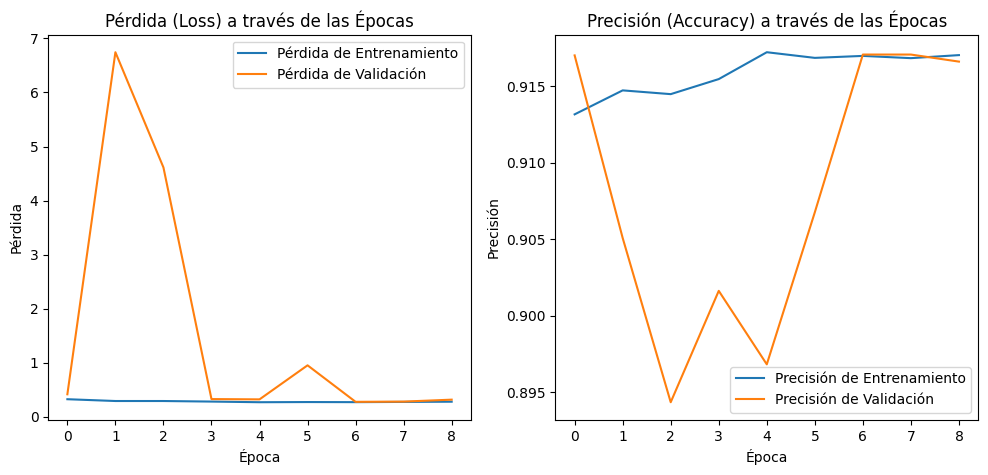

In [27]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida (Loss) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

# Graficar Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión (Accuracy) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.show()

188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step


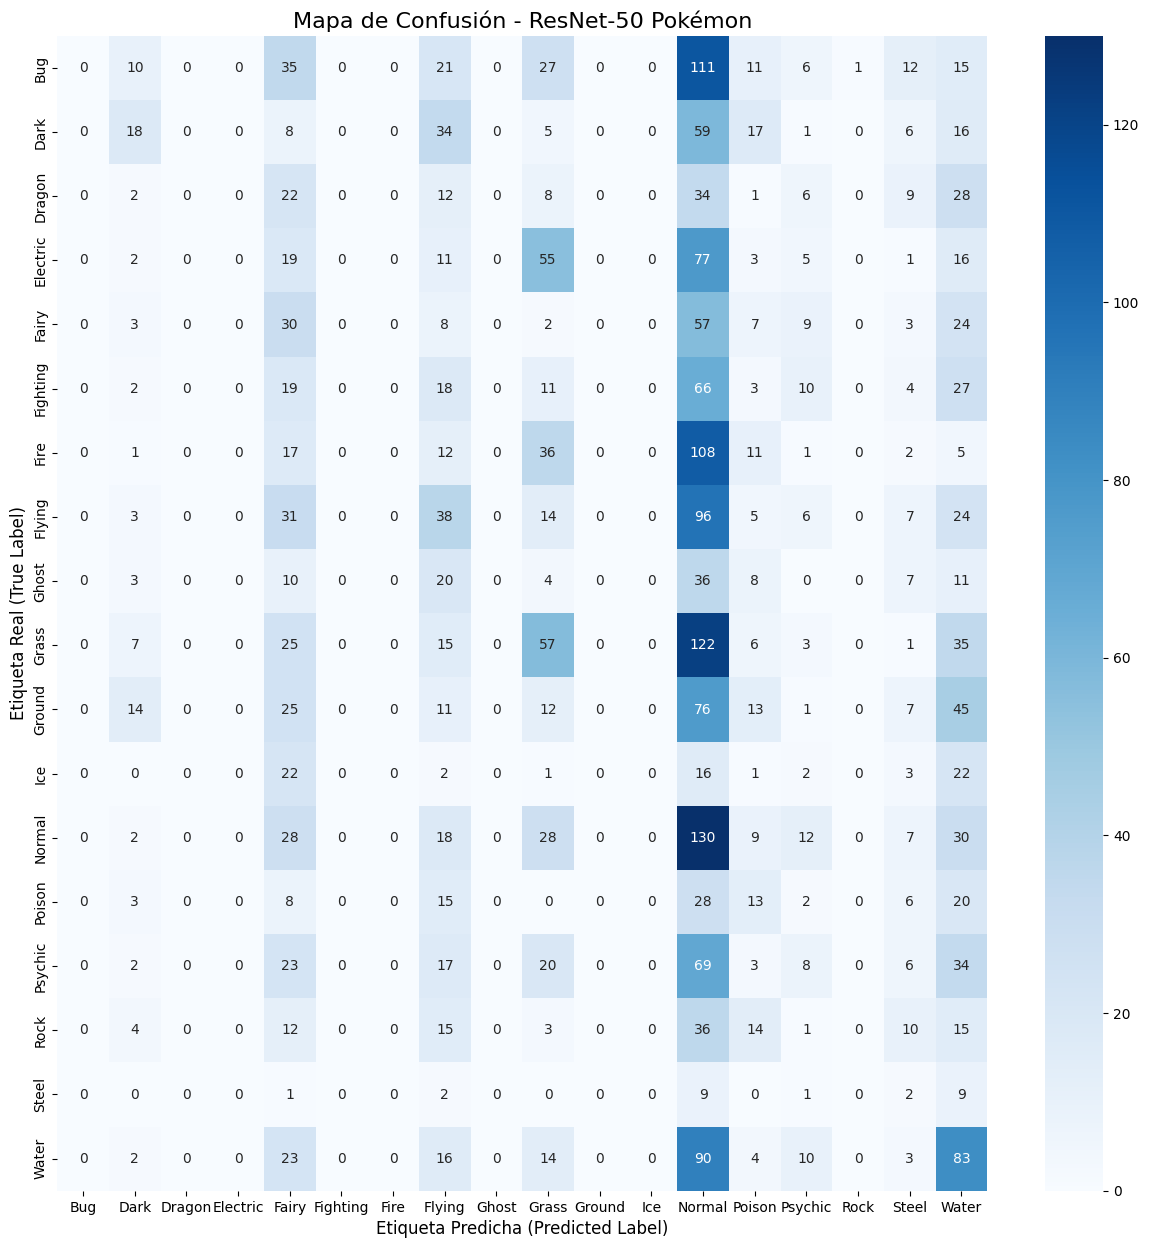

In [28]:
# Matriz de confusion
plt.figure(figsize=(15, 15))
y_pred_probs = model.predict(val_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)
y_true_indices = np.argmax(np.array(list(y_val)), axis=1)

cm = confusion_matrix(y_true_indices, y_pred_indices)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.title('Mapa de Confusión - ResNet-50 Pokémon', fontsize=16)
plt.ylabel('Etiqueta Real (True Label)', fontsize=12)
plt.xlabel('Etiqueta Predicha (Predicted Label)', fontsize=12)

plt.show()



Generando cuadrícula de imágenes aleatorias del set de entrenamiento...
Cuadrícula de imágenes guardada como: grid_imagenes_entrenamiento.png


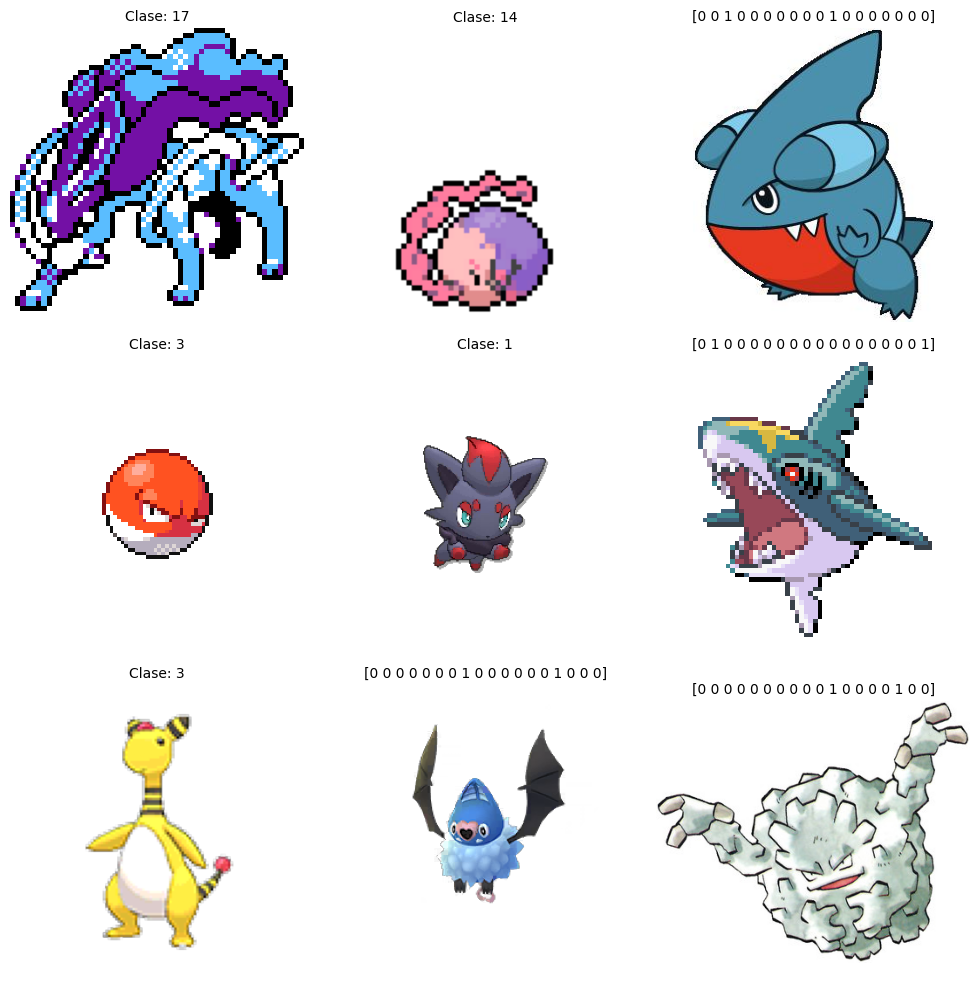

In [29]:
print("\nGenerando cuadrícula de imágenes aleatorias del set de entrenamiento...")

# Definir el tamaño de la cuadrícula
filas = 3
columnas = 3
num_imagenes = filas * columnas

# Crear la figura y los ejes para la cuadrícula
# figsize ajusta el tamaño total de la imagen
fig, axes = plt.subplots(filas, columnas, figsize=(10, 10))

# Obtener 9 índices aleatorios únicos del conjunto de entrenamiento
# Usamos `random.sample` para asegurar que no haya duplicados
try:
    indices_aleatorios = random.sample(range(len(X_train_paths)), k=num_imagenes)
except ValueError:
    print(f"Error: No tienes suficientes imágenes ({len(X_train_paths)}) para una cuadrícula de {num_imagenes}.")
    # En este caso, simplemente salimos o ajustamos num_imagenes
    indices_aleatorios = [] # Salir

if indices_aleatorios:
    # Aplanar el array de ejes (de 2D a 1D) para iterar fácilmente
    for i, ax in enumerate(axes.flat):
        # Obtener el índice aleatorio
        idx = indices_aleatorios[i]

        # Obtener la ruta de la imagen y la etiqueta
        img_path = X_train_paths[idx]
        label = y_train[idx]

        try:
            # Cargar la imagen desde la ruta
            img = mpimg.imread(img_path)

            # Mostrar la imagen en el eje (subplot)
            ax.imshow(img)

            # --- Formatear el título (etiqueta) ---
            # 'y_train' proviene de 'y_binarized', por lo que puede ser un array one-hot
            # (ej. [0, 1, 0, 0]) o un solo número.
            # Este código intenta manejar ambos casos.
            label_str = ""
            if isinstance(label, (np.ndarray, list)):
                # Si es one-hot, encontramos el índice del '1'
                if np.sum(label) == 1:
                    label_str = f"Clase: {np.argmax(label)}"
                else: # Si es otra cosa (ej. multi-label)
                    label_str = str(label)
            else: # Si es un solo número o string
                label_str = f"Clase: {label}"

            ax.set_title(label_str, fontsize=10)

            # Ocultar los ejes (ticks, labels, etc.)
            ax.axis('off')

        except FileNotFoundError:
            print(f"Error: No se pudo encontrar el archivo {img_path}")
            ax.set_title("Archivo no encontrado", fontsize=8)
            ax.axis('off')
        except Exception as e:
            print(f"Error al cargar {img_path}: {e}")
            ax.set_title("Error de carga", fontsize=8)
            ax.axis('off')

    # Ajustar el espaciado para que los títulos no se superpongan
    plt.tight_layout()

    # Guardar la figura en un archivo
    output_filename = "grid_imagenes_entrenamiento.png"
    plt.savefig(output_filename)
    print(f"Cuadrícula de imágenes guardada como: {output_filename}")

    plt.show()
else:
    print("No hay suficientes imágenes para generar la cuadrícula.")

In [36]:
# --- 1. Generar predicciones (usando el modelo 'sigmoid' entrenado) ---
y_pred_probs = model.predict(val_ds)

# --- 2. Convertir probabilidades a etiquetas ---
# 'sigmoid' nos da probabilidades (0.0 a 1.0) para cada clase.
# Decidimos que cualquier cosa por encima del 50% (0.5) es un "Sí".
y_pred = (y_pred_probs > 0.5).astype(int)

# --- 3. Generar el reporte ---
# 'y_val' son las etiquetas reales, 'y_pred' son las que dijo el modelo
# 'class_names' es tu lista de 18 nombres de Pokémon
print(classification_report(y_val, y_pred, target_names=classes))

188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step
              precision    recall  f1-score   support

         Bug       0.00      0.00      0.00       249
        Dark       0.00      0.00      0.00       164
      Dragon       0.00      0.00      0.00       136
    Electric       0.00      0.00      0.00       200
       Fairy       0.00      0.00      0.00       162
    Fighting       0.00      0.00      0.00       185
        Fire       0.00      0.00      0.00       226
      Flying       0.00      0.00      0.00       345
       Ghost       0.00      0.00      0.00       141
       Grass       0.00      0.00      0.00       355
      Ground       0.00      0.00      0.00       271
         Ice       0.00      0.00      0.00       118
      Normal       0.00      0.00      0.00       409
      Poison       0.00      0.00      0.00       301
     Psychic       0.00      0.00      0.00       315
        Rock       0.00      0.00      0.00       231
       Steel       0.00      0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
